# AG-HYPOPT · Trial 12

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_12. Eleven trials recorded. The target rule is the clear winner (plateau at
0.080-0.089 across h_f 3.5-5.5 AND h_s 2.5-7.9; best exp6 0.0803); sim (0.1249) and power (0.1541) are
clearly worse; the h_f edges degrade (0.1165 @ 1.13, 0.0926 @ 9.82). trial_11 closed the low-h_s possibility
(h_s 2.52 -> 0.0873, no gain). The campaign's picture is stable: the target-rule plateau is flat/noise-limited
and exp6's frozen point is within it.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_12'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (11/5 trials)
ID |     ei | params
 1 | 1.1744 | {"bandwidth_rule": "target", "h_f_scale": 5.786573446670075, "h_s_scale": 4.8487816465555325}
 2 | 1.5632 | {"bandwidth_rule": "target", "h_f_scale": 2.750123061109826, "h_s_scale": 8.273946560626296}
 3 | 1.2309 | {"bandwidth_rule": "target", "h_f_scale": 2.379486497415344, "h_s_scale": 6.985013189350365}
 4 | 2.8541 | {"bandwidth_rule": "target", "h_f_scale": 5.242827006464355, "h_s_scale": 7.906253970206584}
 5 | 2.6725 | {"bandwidth_rule": "sim", "h_f_scale": 5.055777489539984, "h_s_scale": 7.2752047198254255}
 6 | 1.3929 | {"bandwidth_rule": "power", "h_f_scale": 3.122103747363556, "h_s_scale": 6.5672842754803264}
 7 | 0.2778 | {"bandwidth_rule": "sim", "h_f_scale": 3.236715354290268, "h_s_scale": 2.477869110282318}
 8 | 1.6658 | {"bandwidth_rule": "sim", "h_f_scale": 11.401607494284665, "h_s_scale": 7.601213140825611}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 4.562845573474837, "h_s_scale": 2.872708987

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The highest-EI proposal is #4 (target, h_f 5.243, h_s 7.906, EI 2.854) - the winning rule inside the plateau.
The next candidates are #5 (sim 5.056/7.275, 2.673) and #8 (sim 11.402/7.601, 1.666), both on the losing
`sim` rule, and #2/#3 (target but at h_f 2.4-2.8, toward the degraded low edge). #9 (target 4.563/2.873) has no
EI shown and repeats the low-h_s region just shown not to help.

Following the evidence and EI, #4 is the sensible pick: target rule, mid-plateau h_f, highest EI.

I choose candidate 4 (target, h_f_scale 5.243, h_s_scale 7.906).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 5.242827006464355, 'h_s_scale': 7.906253970206584}
Running  1nW Trans05 ... 

μ 9.39 -> 5.47 | γ 8.5 -> 5.39 | NLL 0.10


Running  1nW Trans20 ... 

μ 17.32 -> 22.62 | γ 8.5 -> 4.96 | NLL 0.29


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.29 | γ 14.1 -> 13.81 | NLL 0.41


Running 3nW Trans100 ... 

μ 175.71 -> 95.19 | γ 14.1 -> 13.58 | NLL 0.38



Total: 7.8 min


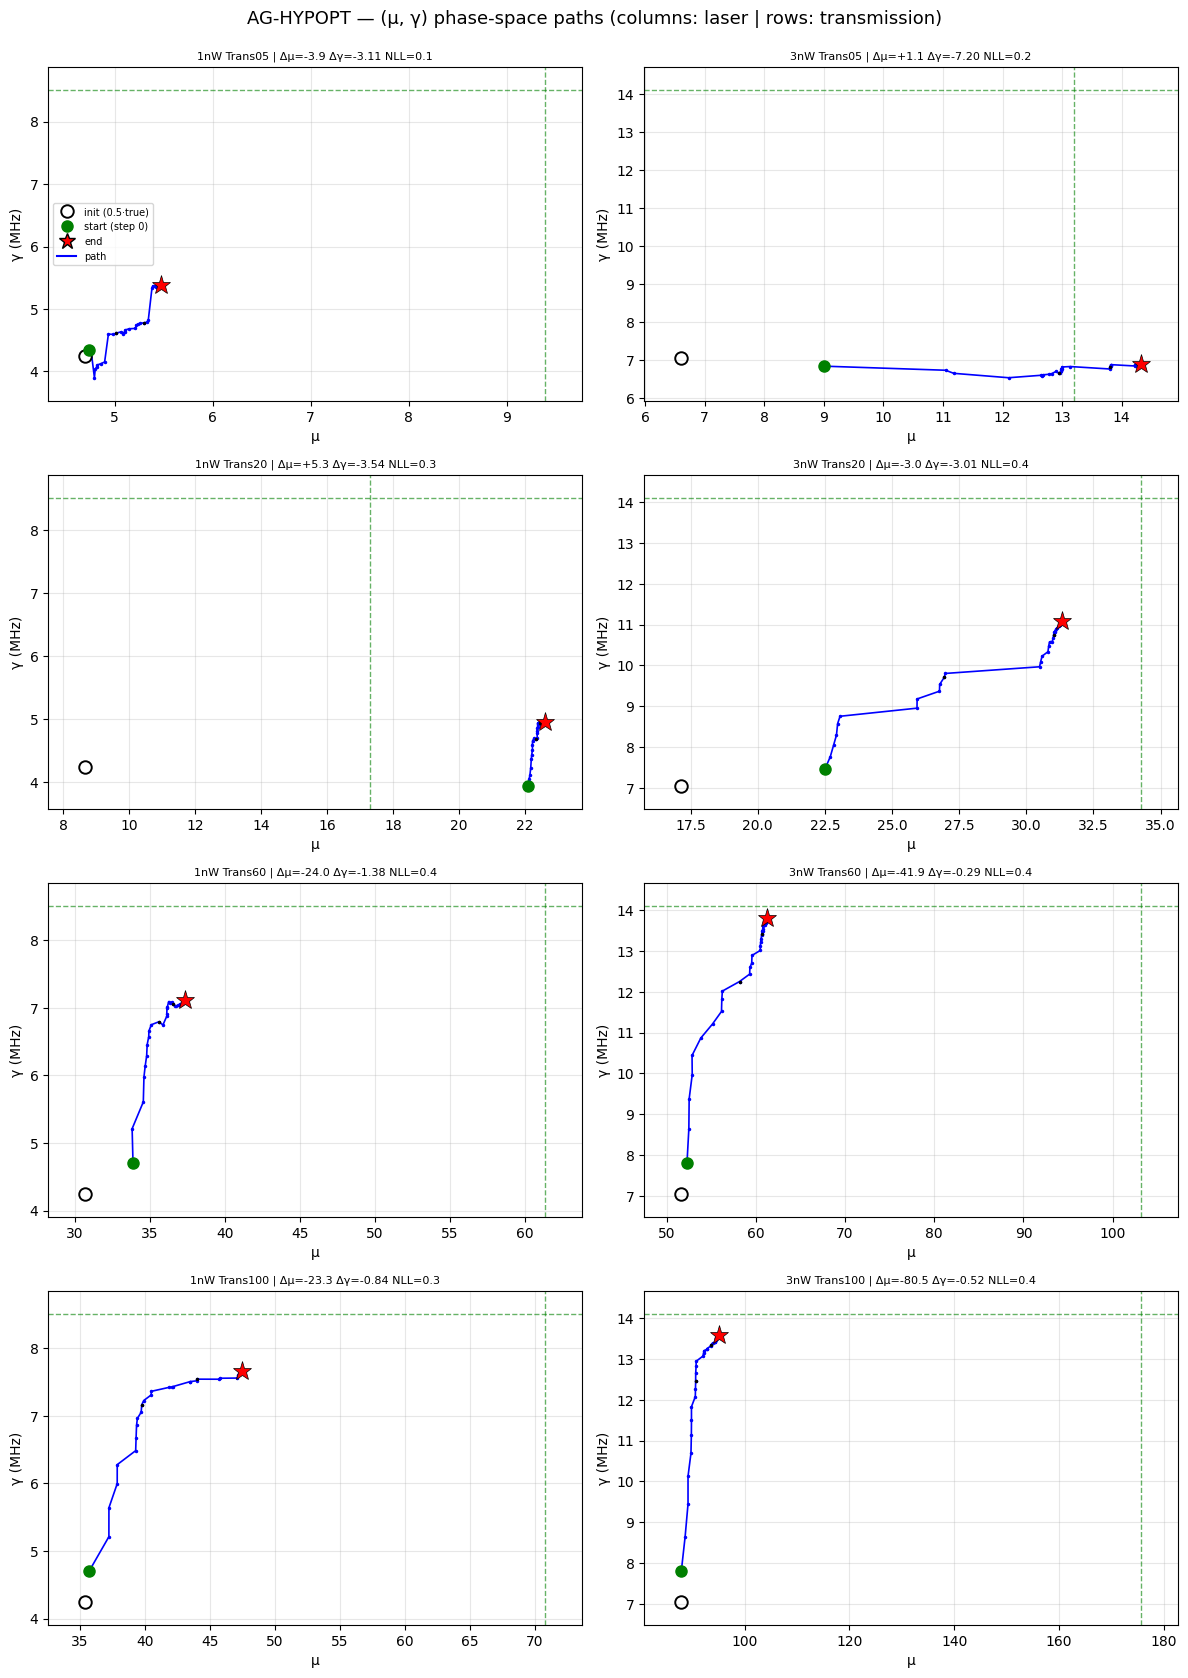

trial finished in 7.8 min
objective = 0.0906 ± 0.0214
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.47   -41.7 |     8.50    5.39   -36.6
1nW Trans20       17.32   22.62   +30.6 |     8.50    4.96   -41.7
1nW Trans60       61.37   37.36   -39.1 |     8.50    7.12   -16.2
1nW Trans100       70.82   47.49   -32.9 |     8.50    7.66    -9.9
3nW Trans05       13.20   14.33    +8.5 |    14.10    6.90   -51.1
3nW Trans20       34.28   31.31    -8.7 |    14.10   11.09   -21.4
3nW Trans60      103.20   61.29   -40.6 |    14.10   13.81    -2.1
3nW Trans100      175.71   95.19   -45.8 |    14.10   13.58    -3.7

weighted objective (T-graded, cap=1.0) = 0.0906 | diverged cells: 0
μ: RMSE 34.304 (rel 33.9%, bias -21.279) | γ: RMSE 3.280 (rel 28.5%, bias -2.487)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

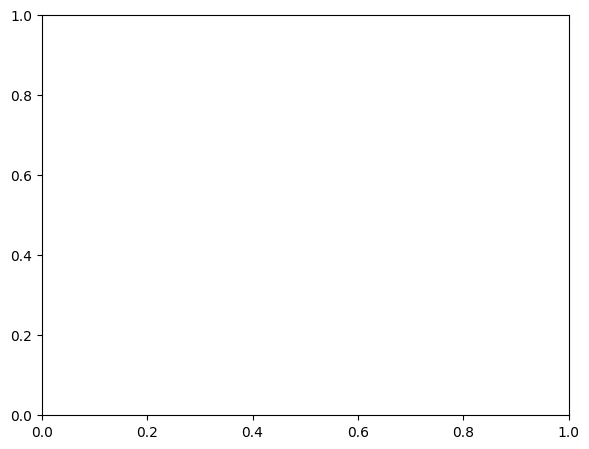

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0906 ± 0.0214, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 5.243, h_s_scale = 7.906 (highest-EI proposal).

Usual pattern: mu undershoots most cells (+30.6 % at 1nW Trans20, +8.5 % at 3nW Trans05), gamma
underestimates all cells (1nW Trans20 -41.7 %, 3nW Trans05 -51.1 %). Another plateau sample, at the upper
end (0.0906).

The target plateau now has nine samples spanning 0.0803-0.0906 (mean ~0.0855) with no trend. This trial
adds another mid/upper-plateau point. The picture is unchanged and stable: the target rule is the winner and
its objective over h_f ~3.5-5.5, h_s ~2.5-7.9 is flat at the campaign's precision; exp6's 0.0803 remains the
lowest individual value.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 12 (target rule, h_f 5.243, h_s 7.906) scores objective 0.0906 ± 0.0214, another sample from the flat target plateau.
**Key insight:** Nine plateau samples now span 0.0803-0.0906 with no trend; the target-rule objective is flat/noise-limited across the whole tested band.

Notes for Anuar (optional, not acted on): none new.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 12 (target rule, h_f 5.243, h_s 7.906) scores objective 0.0906 ± 0.0214, another sample from the flat target plateau."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Nine plateau samples now span 0.0803-0.0906 with no trend; the target-rule objective is flat/noise-limited across the whole tested band."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_12 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_13.ipynb. Open it and follow its cells from the top.
